# Teacher Recruitment, Retention & Development — Newsletter Analysis

Analysis for Gemma Moss's BERA presentation (30 March 2026):  
**"Teacher recruitment, retention and development: perspectives from policy and from research"**

Source: ESRC Education Research Programme Newsletter, issues 1–104 (July 2023 – Feb 2026)  
Dataset: `data/preprocessed/newsletters_preprocessed.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

df = pd.read_csv('../data/preprocessed/newsletters_preprocessed.csv')
df['issue_date'] = pd.to_datetime(df['issue_date'], dayfirst=True, errors='coerce')

rrd = df[df['new_theme'] == 'teacher_rrd'].copy()

print(f"Total newsletter items (all themes): {len(df)}")
print(f"Teacher RR&D items: {len(rrd)}")
print(f"Issues covered: {rrd['newsletter_number'].nunique()} of {df['newsletter_number'].nunique()}")
print(f"Date range: {rrd['issue_date'].min().strftime('%b %Y')} – {rrd['issue_date'].max().strftime('%b %Y')}")

Total newsletter items (all themes): 1363
Teacher RR&D items: 203
Issues covered: 100 of 102
Date range: Jul 2023 – Mar 2026


---
## 1. How does teacher RR&D compare in volume to other themes?

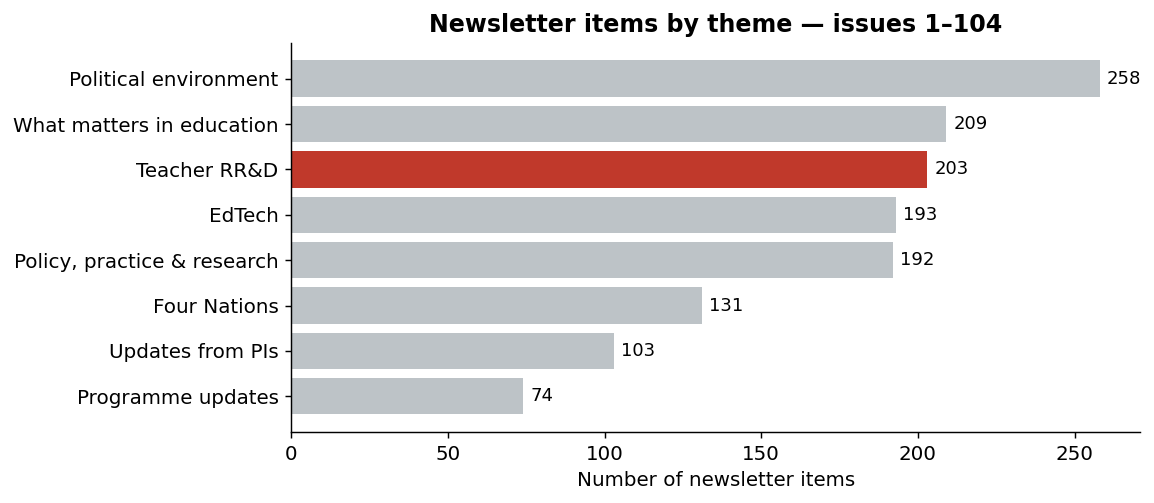

---
## 2. Coverage over time — items per issue

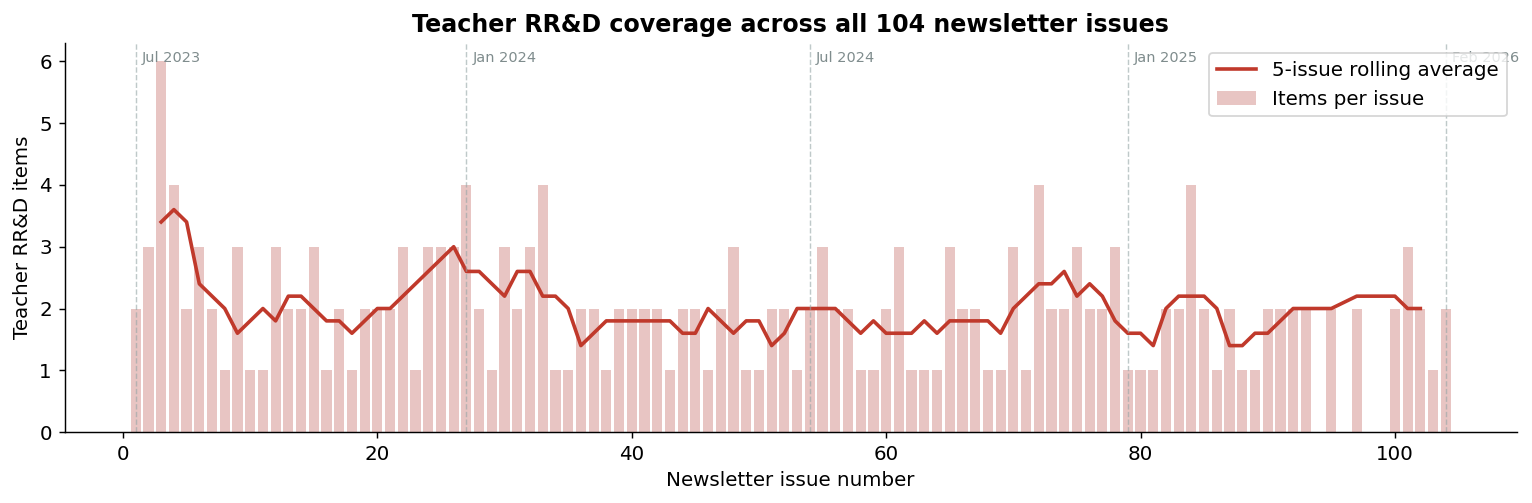

Average items per issue: 2.0
Max in a single issue: 6 (issue 3)


In [3]:
# Items per newsletter issue
items_per_issue = (
    rrd.groupby('newsletter_number')
    .size()
    .reset_index(name='count')
)

# Rolling 5-issue average to show trend
items_per_issue['rolling_avg'] = items_per_issue['count'].rolling(5, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(items_per_issue['newsletter_number'], items_per_issue['count'],
       color='#e8c5c3', width=0.8, label='Items per issue')
ax.plot(items_per_issue['newsletter_number'], items_per_issue['rolling_avg'],
        color='#c0392b', linewidth=2, label='5-issue rolling average')
ax.set_xlabel('Newsletter issue number')
ax.set_ylabel('Teacher RR&D items')
ax.set_title('Teacher RR&D coverage across all 104 newsletter issues', fontweight='bold')
ax.legend()

# Add approximate year markers
for issue, label in [(1, 'Jul 2023'), (27, 'Jan 2024'), (54, 'Jul 2024'), (79, 'Jan 2025'), (104, 'Feb 2026')]:
    ax.axvline(issue, color='#95a5a6', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(issue + 0.5, ax.get_ylim()[1] * 0.95, label, fontsize=8, color='#7f8c8d')

plt.tight_layout()
plt.savefig('../data/interim/fig2_coverage_over_time.png', bbox_inches='tight')
plt.show()

print(f"Average items per issue: {items_per_issue['count'].mean():.1f}")
print(f"Max in a single issue: {items_per_issue['count'].max()} (issue {items_per_issue.loc[items_per_issue['count'].idxmax(), 'newsletter_number']})")

---
## 3. Who is covering teacher RR&D? — Source sectors

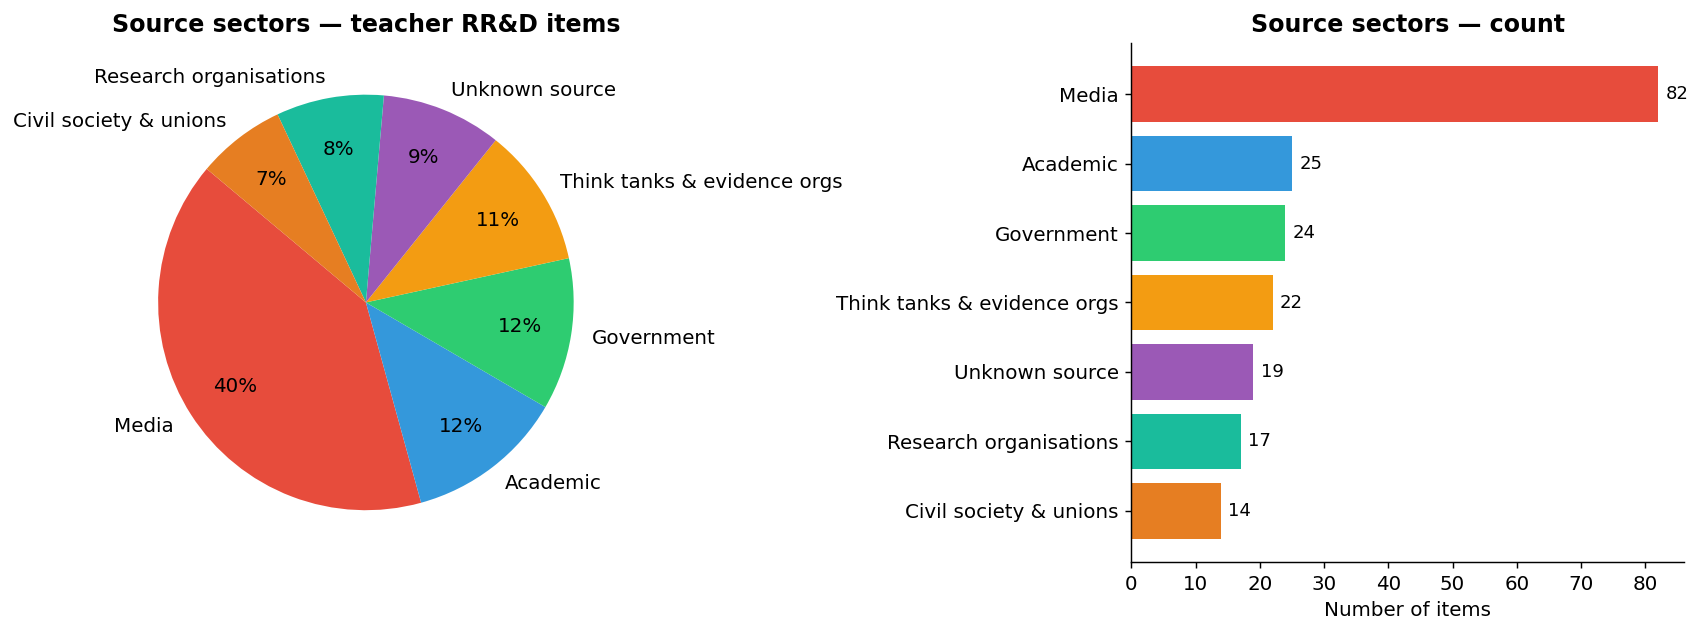

In [4]:
SECTOR_LABELS = {
    'media_sector':                           'Media',
    'academic_sector':                        'Academic',
    'government_public_sector':               'Government',
    'knowledge_mobiliser_think_tank_sector':  'Think tanks & evidence orgs',
    'research_evidence_sector':               'Research organisations',
    'civil_society_nonprofit_sector':         'Civil society & unions',
    'commercial_private_sector':              'Commercial',
    'digital_social_media_platforms':         'Social / video',
    'other_miscellaneous':                    'Other',
}

sector_counts = (
    rrd['org_broad_category']
    .map(SECTOR_LABELS)
    .value_counts(dropna=False)
)
sector_counts.index = sector_counts.index.fillna('Unknown source')

COLOURS = [
    '#e74c3c', '#3498db', '#2ecc71', '#f39c12',
    '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6', '#bdc3c7'
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Pie
wedges, texts, autotexts = ax1.pie(
    sector_counts.values,
    labels=sector_counts.index,
    autopct=lambda p: f'{p:.0f}%' if p > 4 else '',
    colors=COLOURS[:len(sector_counts)],
    startangle=140,
    pctdistance=0.75,
)
ax1.set_title('Source sectors — teacher RR&D items', fontweight='bold')

# Bar for easier reading
bars = ax2.barh(sector_counts.index[::-1], sector_counts.values[::-1],
                color=COLOURS[:len(sector_counts)][::-1])
ax2.bar_label(bars, padding=4, fontsize=10)
ax2.set_xlabel('Number of items')
ax2.set_title('Source sectors — count', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/interim/fig3_source_sectors.png', bbox_inches='tight')
plt.show()

---
## 4. Top organisations

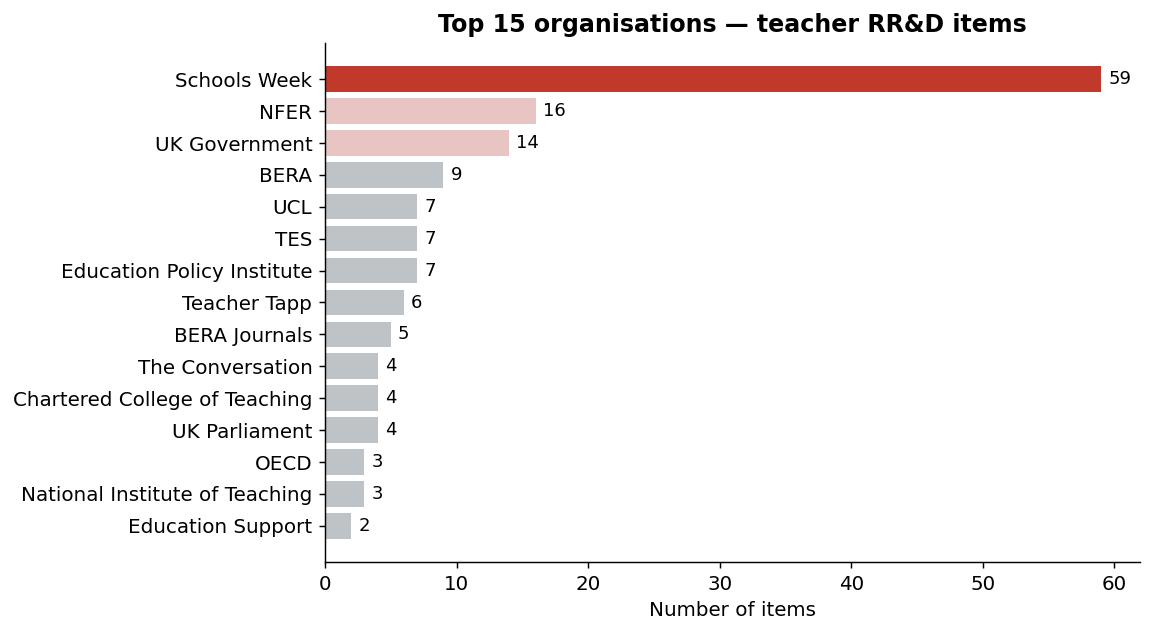


Unmapped organisations (no lookup entry): 19 items


In [5]:
ORG_LABELS = {
    'schools_week': 'Schools Week',
    'nfer': 'NFER',
    'uk_government': 'UK Government',
    'bera': 'BERA',
    'ucl': 'UCL',
    'tes': 'TES',
    'epi': 'Education Policy Institute',
    'teacher_tapp': 'Teacher Tapp',
    'bera_journals': 'BERA Journals',
    'conversation': 'The Conversation',
    'chartered_college_of_teaching': 'Chartered College of Teaching',
    'uk_parliament': 'UK Parliament',
    'oecd': 'OECD',
    'national_institute_of_teaching': 'National Institute of Teaching',
    'education_support_charity': 'Education Support',
    'guardian': 'The Guardian',
    'nuffield': 'Nuffield Foundation',
    'nasuwt_teachers_union': 'NASUWT',
    'national_education_union': 'NEU',
    'sutton_trust': 'Sutton Trust',
}

top_orgs = (
    rrd['organisation']
    .map(lambda x: ORG_LABELS.get(x, x))
    .value_counts()
    .head(15)
)

colours = ['#c0392b' if i == 0 else ('#e8c5c3' if i < 3 else '#bdc3c7')
           for i in range(len(top_orgs))]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_orgs.index[::-1], top_orgs.values[::-1], color=colours[::-1])
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel('Number of items')
ax.set_title('Top 15 organisations — teacher RR&D items', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/interim/fig4_top_orgs.png', bbox_inches='tight')
plt.show()

print(f"\nUnmapped organisations (no lookup entry): {rrd['organisation'].isna().sum()} items")

---
## 5. What type of content is being covered?

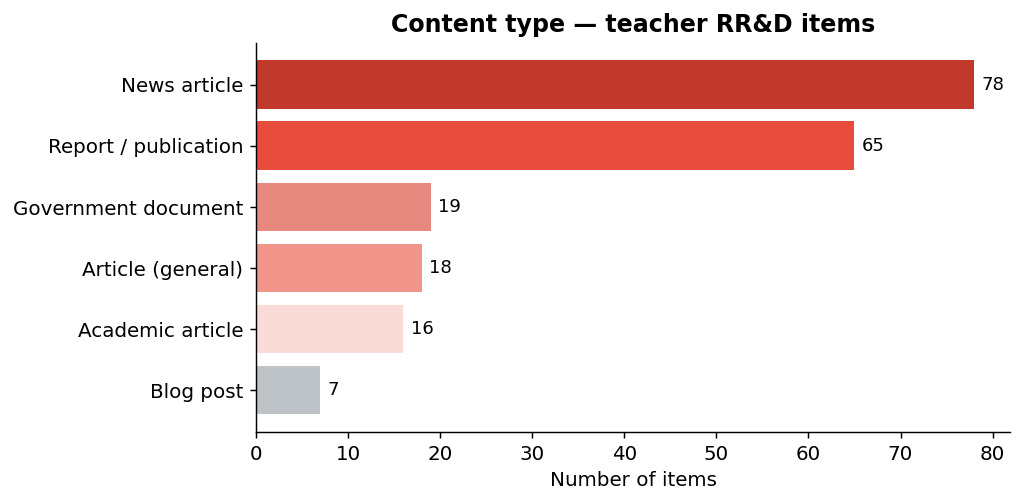

In [6]:
ITEM_LABELS = {
    'news_article':        'News article',
    'report':              'Report / publication',
    'government_document': 'Government document',
    'article':             'Article (general)',
    'academic_article':    'Academic article',
    'blog_post':           'Blog post',
    'tweet':               'Tweet',
    'video':               'Video',
    'linkedin_post':       'LinkedIn post',
    'social_media_post':   'Social media',
}

item_counts = (
    rrd['item_type']
    .map(ITEM_LABELS)
    .value_counts()
)

ITEM_COLOURS = ['#c0392b', '#e74c3c', '#e8897f', '#f1948a',
                '#fadbd8', '#bdc3c7', '#95a5a6', '#7f8c8d']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(item_counts.index[::-1], item_counts.values[::-1],
               color=ITEM_COLOURS[:len(item_counts)][::-1])
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel('Number of items')
ax.set_title('Content type — teacher RR&D items', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/interim/fig5_item_types.png', bbox_inches='tight')
plt.show()

---
## 6. Key reports and publications

Academic articles and formal reports — these are likely to be most useful as presentation references.

In [7]:
key_items = (
    rrd[rrd['item_type'].isin(['academic_article', 'report', 'government_document'])]
    [['title', 'organisation', 'item_type', 'issue_date', 'link']]
    .sort_values('issue_date')
    .reset_index(drop=True)
)

key_items['organisation'] = key_items['organisation'].map(lambda x: ORG_LABELS.get(x, x))
key_items['issue_date'] = key_items['issue_date'].dt.strftime('%b %Y')

pd.set_option('display.max_colwidth', 90)
print(f"Academic articles, reports & government documents: {len(key_items)} items\n")
key_items

Academic articles, reports & government documents: 100 items



,title,organisation,item_type,issue_date,link
0,NFER Research - Policy options for a long-term teacher pay and financial incentives st...,NFER,report,Jul 2023,https://www.nfer.ac.uk/policy-options-for-a-long-term-teacher-pay-and-financial-incent...
1,'Being well' and 'doing well': Exploring the relationship between student and teacher ...,BERA,report,Jul 2023,https://www.bera.ac.uk/blog/being-well-and-doing-well-exploring-the-relationship-betwe...
2,Re pay awards: School Teachers' Review Body 33rd report: 2023,UK Government,government_document,Jul 2023,https://www.gov.uk/government/publications/school-teachers-review-body-33rd-report-2023
3,Report from NEU - High work intensity makes teacher's jobs more demanding post-pandemic,UCL,academic_article,Jul 2023,https://www.ucl.ac.uk/ioe/news/2023/jul/high-work-intensity-makes-teachers-jobs-more-d...
4,DfE - Teacher and Leader development: ECF and NPQs 2022 Experimental statistics.,UK Government,government_document,Jul 2023,https://www.gov.uk/government/statistics/teacher-and-leader-development-ecf-and-npqs-2022
...,...,...,...,...,...
95,Department for Education - New employer grant to boost quality in early years education,UK Government,government_document,Feb 2026,https://www.gov.uk/government/news/new-employer-grant-to-boost-quality-in-early-years-...
96,National Foundation for Education Research - What helps to improve teacher retention? ...,NFER,report,Feb 2026,https://www.nfer.ac.uk/publications/what-helps-to-improve-teacher-retention
97,The Chartered College of Teaching - How to retain teacher-mothers: Practical,Chartered College of Teaching,report,Feb 2026,https://my.chartered.college/impact_article/how-to-retain-teacher-mothers-practical-st...
98,"Department for Education - 6,500 additional teachers delivery plan",UK Government,government_document,Mar 2026,https://www.gov.uk/government/publications/every-child-achieving-and-thriving/6500-add...


---
## 7. Summary statistics for the presentation

In [8]:
total = len(rrd)
issues_covered = rrd['newsletter_number'].nunique()
total_issues = df['newsletter_number'].nunique()
date_start = rrd['issue_date'].min().strftime('%B %Y')
date_end   = rrd['issue_date'].max().strftime('%B %Y')
top_source = rrd['organisation'].value_counts().index[0]
top_source_n = rrd['organisation'].value_counts().iloc[0]
pct_of_all = 100 * total / len(df)

print("=" * 55)
print("HEADLINE NUMBERS FOR PRESENTATION")
print("=" * 55)
print(f"Period covered:         {date_start} – {date_end}")
print(f"Total newsletter items: {len(df):,} across {total_issues} issues")
print(f"Teacher RR&D items:     {total} ({pct_of_all:.0f}% of all content)")
print(f"Issues featuring it:    {issues_covered}/{total_issues}")
print(f"Avg items per issue:    {total/issues_covered:.1f}")
print(f"Top source:             Schools Week ({top_source_n} items)")
print(f"Academic/report items:  {len(key_items)}")
print(f"Govt documents:         {(rrd['item_type']=='government_document').sum()}")
print("=" * 55)

HEADLINE NUMBERS FOR PRESENTATION
Period covered:         July 2023 – March 2026
Total newsletter items: 1,363 across 102 issues
Teacher RR&D items:     203 (15% of all content)
Issues featuring it:    100/102
Avg items per issue:    2.0
Top source:             Schools Week (59 items)
Academic/report items:  100
Govt documents:         19


---
## 8. Export for Gemma

In [9]:
import os
os.makedirs('../data/outputs', exist_ok=True)

# Full teacher_rrd dataset with readable labels
export = rrd[['newsletter_number', 'issue_date', 'title', 'description', 'link',
              'organisation', 'org_broad_category', 'item_type']].copy()
export['organisation']      = export['organisation'].map(lambda x: ORG_LABELS.get(x, x))
export['org_broad_category']= export['org_broad_category'].map(SECTOR_LABELS)
export['item_type']         = export['item_type'].map(ITEM_LABELS)
export['issue_date']        = export['issue_date'].dt.strftime('%d %b %Y')
export = export.sort_values('newsletter_number').reset_index(drop=True)

with pd.ExcelWriter('../data/outputs/teacher_rrd_analysis.xlsx') as xw:
    export.to_excel(xw, sheet_name='All teacher RR&D items', index=False)
    key_items.to_excel(xw, sheet_name='Reports & academic articles', index=False)
    sector_counts.reset_index().rename(columns={'index':'sector','org_broad_category':'count'}).to_excel(
        xw, sheet_name='Source sectors', index=False)
    top_orgs.reset_index().rename(columns={'index':'organisation','organisation':'count'}).to_excel(
        xw, sheet_name='Top organisations', index=False)

print("Saved: data/outputs/teacher_rrd_analysis.xlsx")
print("Figures saved to: data/interim/fig1_*.png through fig5_*.png")

Saved: data/outputs/teacher_rrd_analysis.xlsx
Figures saved to: data/interim/fig1_*.png through fig5_*.png


---
## 9. Rolling monthly average — teacher RR&D coverage

How consistently has the newsletter covered teacher RR&D across the programme's lifetime?

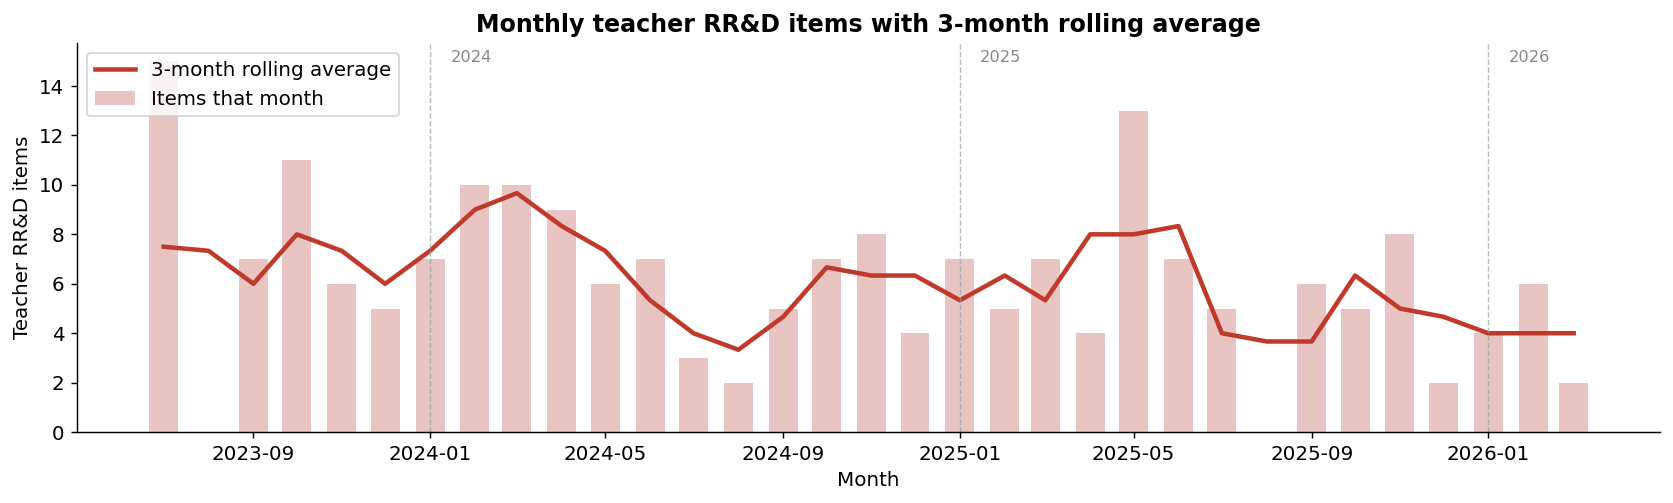

Peak month: Jul 2023 (15 items)
Overall monthly average: 6.2 items


In [10]:

# Monthly item counts
monthly_counts = (
    rrd.groupby(rrd['issue_date'].dt.to_period('M'))
    .size()
    .rename_axis('period')
)

# Convert to timestamp index, fill missing months with 0
full_range = pd.period_range(monthly_counts.index.min(), monthly_counts.index.max(), freq='M')
monthly_counts = monthly_counts.reindex(full_range, fill_value=0)

monthly = monthly_counts.reset_index()
monthly.columns = ['period', 'count']
monthly['month_dt'] = monthly['period'].dt.to_timestamp()

# 3-month rolling average
monthly['rolling_3m'] = monthly['count'].rolling(3, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(monthly['month_dt'], monthly['count'], width=20, color='#e8c5c3', label='Items that month')
ax.plot(monthly['month_dt'], monthly['rolling_3m'], color='#c0392b', linewidth=2.5,
        label='3-month rolling average')

for yr in ['2024', '2025', '2026']:
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='#95a5a6', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(pd.Timestamp(f'{yr}-01-15'), ax.get_ylim()[1] * 0.95, yr, fontsize=9, color='#7f8c8d')

ax.set_xlabel('Month')
ax.set_ylabel('Teacher RR&D items')
ax.set_title('Monthly teacher RR&D items with 3-month rolling average', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/interim/fig6_rolling_monthly.png', bbox_inches='tight')
plt.show()

print(f"Peak month: {monthly.loc[monthly['count'].idxmax(), 'month_dt'].strftime('%b %Y')} "
      f"({monthly['count'].max()} items)")
print(f"Overall monthly average: {monthly['count'].mean():.1f} items")


---
## 10. Framing analysis — how is the topic being discussed?

Each item is tagged with one or more **frames** based on keywords in its title and description.  
An item can carry multiple frames (e.g. a story about pay *and* retention gets both tags).

Frames defined:
- **Recruitment / supply** — shortage, vacancy, bursary, incentive, supply, ITT, PGCE
- **Retention / leaving** — retain, retention, leaving, exodus, turnover, quit, lost teachers
- **Pay / conditions** — pay, salary, wage, reward, financial incentive
- **Wellbeing / workload** — wellbeing, workload, burnout, mental health, stress
- **Training / early career** — ECT, early career, CPD, NPQ, induction, initial teacher training
- **Diversity / inclusion** — diversity, ethnic, minority, BAME, gender
- **Policy / government action** — DfE, minister, policy, reform, legislation, government

Items matching at least one frame: 161 / 203
Unframed items: 42

Average frames per item: 1.4



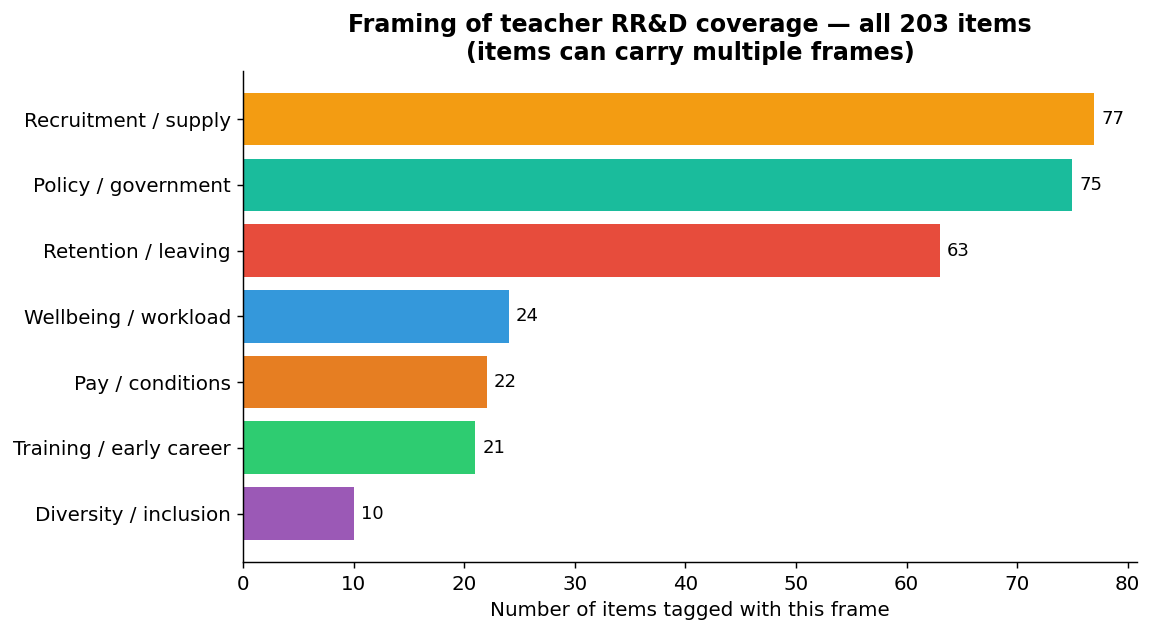

In [11]:

import re

FRAMES = {
    'Recruitment / supply':     r'recruit|shortage|vacanc|bursary|incentive|supply teacher|itt\b|pgce|initial teacher',
    'Retention / leaving':      r'retent|retain|leaving|exodus|turnover|quit|lost teacher|leave the profession',
    'Pay / conditions':         r'\bpay\b|salary|salaries|wage|financial reward|pay award|pay rise|pay deal',
    'Wellbeing / workload':     r'wellbeing|well-being|workload|work-load|burnout|burn-out|mental health|stress',
    'Training / early career':  r'\bect\b|early career|cpd\b|npq\b|induction|initial teacher training|trainee|student teacher',
    'Diversity / inclusion':    r'divers|ethnic|minorit|bame|black teacher|gender',
    'Policy / government':      r'\bdfe\b|department for education|minister|policy|reform|legislation|government',
}

# Match against title + description combined
rrd['text_for_framing'] = (
    rrd['title'].fillna('') + ' ' + rrd['description'].fillna('')
).str.lower()

for frame, pattern in FRAMES.items():
    rrd[frame] = rrd['text_for_framing'].str.contains(pattern, regex=True).astype(int)

frame_cols = list(FRAMES.keys())
frame_totals = rrd[frame_cols].sum().sort_values(ascending=True)

# Items with no frame matched
unframed = (rrd[frame_cols].sum(axis=1) == 0).sum()
print(f"Items matching at least one frame: {len(rrd) - unframed} / {len(rrd)}")
print(f"Unframed items: {unframed}")
print(f"\nAverage frames per item: {rrd[frame_cols].sum(axis=1).mean():.1f}\n")

FRAME_COLOURS = ['#9b59b6', '#2ecc71', '#e67e22', '#3498db', '#e74c3c', '#1abc9c', '#f39c12']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(frame_totals.index, frame_totals.values,
               color=FRAME_COLOURS[:len(frame_totals)])
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel('Number of items tagged with this frame')
ax.set_title('Framing of teacher RR&D coverage — all 203 items\n(items can carry multiple frames)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../data/interim/fig7_framing_counts.png', bbox_inches='tight')
plt.show()


---
## 11. How does framing shift over time?

Quarterly counts per frame — does the balance between recruitment, retention, pay, wellbeing etc. change as the programme progresses?

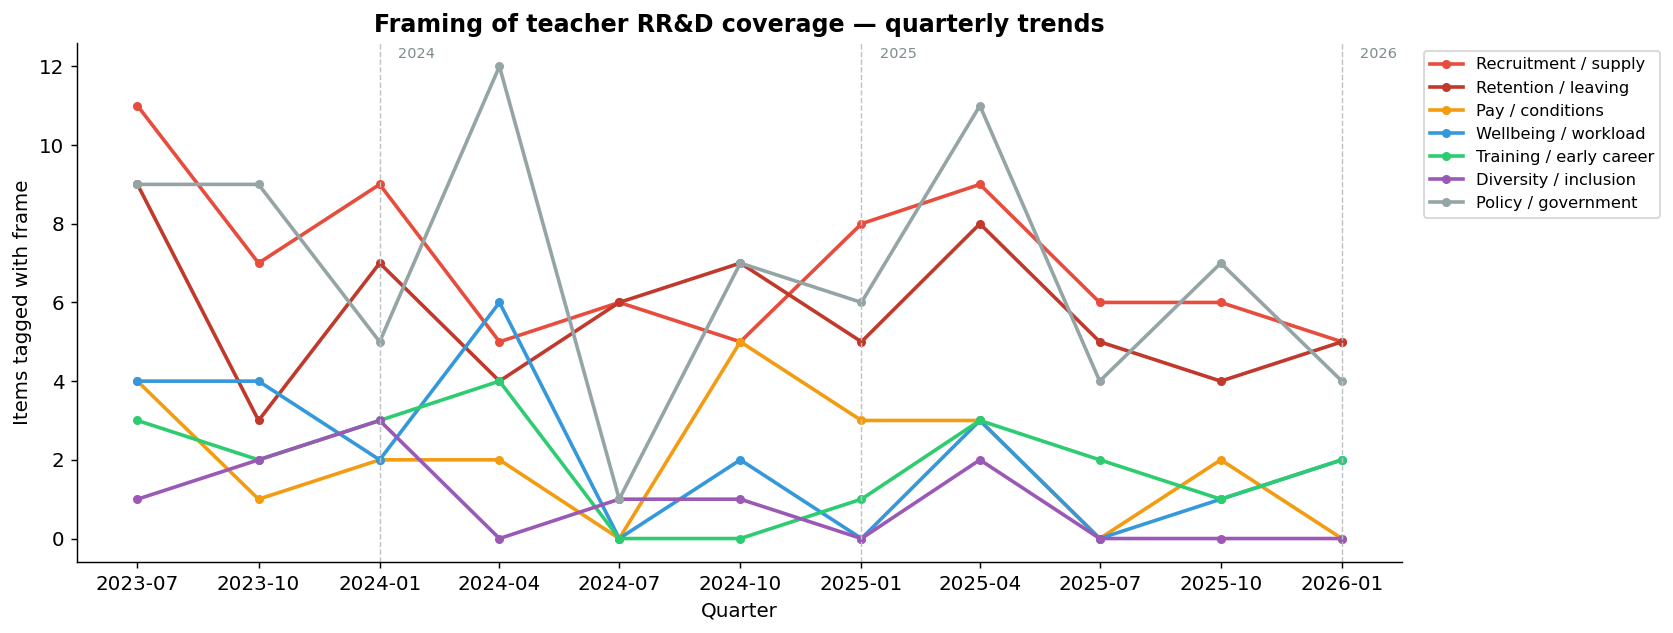

Dominant frame per quarter:
  2023Q3:  Recruitment / supply (11 items)
  2023Q4:  Policy / government (9 items)
  2024Q1:  Recruitment / supply (9 items)
  2024Q2:  Policy / government (12 items)
  2024Q3:  Recruitment / supply (6 items)
  2024Q4:  Retention / leaving (7 items)
  2025Q1:  Recruitment / supply (8 items)
  2025Q2:  Policy / government (11 items)
  2025Q3:  Recruitment / supply (6 items)
  2025Q4:  Policy / government (7 items)
  2026Q1:  Recruitment / supply (5 items)


In [12]:

# Quarterly frame counts
rrd['quarter'] = rrd['issue_date'].dt.to_period('Q')
quarterly_frames = (
    rrd.groupby('quarter')[frame_cols]
    .sum()
    .reset_index()
)
quarterly_frames['quarter_dt'] = quarterly_frames['quarter'].dt.to_timestamp()

# Line chart — one line per frame
fig, ax = plt.subplots(figsize=(13, 5))

LINE_COLOURS = {
    'Recruitment / supply':    '#e74c3c',
    'Retention / leaving':     '#c0392b',
    'Pay / conditions':        '#f39c12',
    'Wellbeing / workload':    '#3498db',
    'Training / early career': '#2ecc71',
    'Diversity / inclusion':   '#9b59b6',
    'Policy / government':     '#95a5a6',
}

for frame in frame_cols:
    ax.plot(quarterly_frames['quarter_dt'], quarterly_frames[frame],
            label=frame, color=LINE_COLOURS[frame], linewidth=2, marker='o', markersize=4)

# Year markers
for yr in ['2024', '2025', '2026']:
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='#bdc3c7', linestyle='--', linewidth=0.8)
    ax.text(pd.Timestamp(f'{yr}-01-15'), ax.get_ylim()[1] * 0.97, yr, fontsize=8, color='#7f8c8d')

ax.set_xlabel('Quarter')
ax.set_ylabel('Items tagged with frame')
ax.set_title('Framing of teacher RR&D coverage — quarterly trends', fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../data/interim/fig8_framing_over_time.png', bbox_inches='tight')
plt.show()

# Print dominant frame per quarter
print("Dominant frame per quarter:")
dominant = quarterly_frames.set_index('quarter_dt')[frame_cols].idxmax(axis=1)
for dt, frame in dominant.items():
    q_label = pd.Period(dt, freq='Q')
    count = quarterly_frames.loc[quarterly_frames['quarter_dt'] == dt, frame].values[0]
    print(f"  {q_label}:  {frame} ({count} items)")
